Installing Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

import xgboost as xgb 

import scipy.stats as stats 
from scipy.stats import chi2_contingency, boxcox

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm 

In [2]:
pip install statsmodels 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

Reading the Data

In [4]:
data = pd.read_csv("C:/Users/Saee Beri/OneDrive/Desktop/HDS Project/Maternal Health Risk Data Set.csv")

In [5]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Body temperature in Fahrenheit

used to train a model that predicts the pregnancy risk level based on a woman's vital signs.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [7]:
data[data.duplicated(keep='first')]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
67,19,120,80,7.0,98.0,70,mid risk
72,19,120,80,7.0,98.0,70,mid risk
97,19,120,80,7.0,98.0,70,mid risk
106,50,140,90,15.0,98.0,90,high risk
107,25,140,100,6.8,98.0,80,high risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


More than a half of the rows are duplicated

In [8]:
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


SystolicBP is reading, indicating the pressure in arteries when the heart beats and pumps blood. 

DiastolicBP is the pressure in the arteries when the heart is at rest between beats. 

In [44]:
len(data[data.Age < 13])

39

Medically, these cases are considered high-risk due to biological and health factors.

39 young girls below 13 years are under pregnancy risk analysis, which helps the model learn patterns for extreme age groups.

In [9]:
data[data.Age > 60]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
114,63,140,90,15.0,98.0,90,high risk
313,62,120,80,6.9,98.0,66,low risk
322,65,90,60,6.9,98.0,70,low risk
326,66,85,60,6.9,98.0,86,low risk
338,70,85,60,6.9,102.0,70,low risk
339,65,120,90,6.9,103.0,76,low risk
435,65,130,80,15.0,98.0,86,high risk
502,63,140,90,15.0,98.0,90,high risk


explore observations with ages over 60 and above 13 years old.

displays only elderly patients (Age > 60)

Some elderly patients are labeled high risk (e.g., age 63 and 65).

Some elderly patients are still labeled low risk, risk is determined not just by age, other factors like BP and blood sugar also matter.

In [11]:
data.BodyTemp.value_counts()

BodyTemp
98.0     804
101.0     98
102.0     66
100.0     20
103.0     13
99.0      10
98.4       2
98.6       1
Name: count, dtype: int64

observations with low heart rate.

all patients whose heart rate is less than 60 beats per minute

In [12]:
data[data.HeartRate < 60]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


There are 2 very young patients (16 years old) 

Their heart rate is recorded as 7 beats per minute or might be 70

Both are marked as low risk

This output shows two abnormal heart rate readings, which are most likely data entry errors and must be cleaned before training your pregnancy risk model.

Data Cleaning

In [13]:
# create copy of the dataset
df = data.copy()

cleans your dataset by removing repeated data and fixing the row numbering.

In [14]:
df = df.drop_duplicates().reset_index(drop=True)

In [15]:
df.shape

(452, 7)

452 rows Number of records (patients) 452 pregnant women

7 columns Number of features / variables. 7 health measurements recorded

In [16]:
df.HeartRate.mode()

0    70
Name: HeartRate, dtype: int64

HeartRate column, 70 occurs more times than any other heart rate value.

0 it just shows the position of the mode value. 

This replaces all values 7 with 70 in those selected rows.

In [17]:
df.loc[df.HeartRate == 7, "HeartRate"] = 70

Feature encoding for categorical variable

In [18]:
df.RiskLevel.unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

high risk – The mother has high medical risk during pregnancy -> 2

mid risk – The mother has moderate risk. -> 1

low risk – The mother has low or minimal risk. -> 0

In [19]:
df.replace({"high risk":2, "mid risk":1, "low risk":0}, inplace=True)
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


This process is called Label Encoding.

low risk - 0
mid risk - 1
high risk - 2

Machine learning models cannot understand text labels, so we convert them into numbers.

<Axes: >

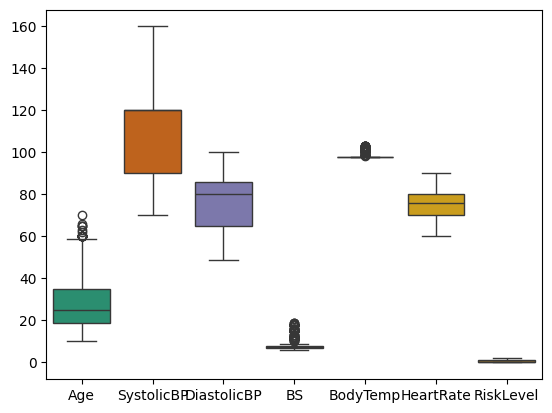

In [20]:
sns.set_palette("Dark2")

sns.boxplot(df)

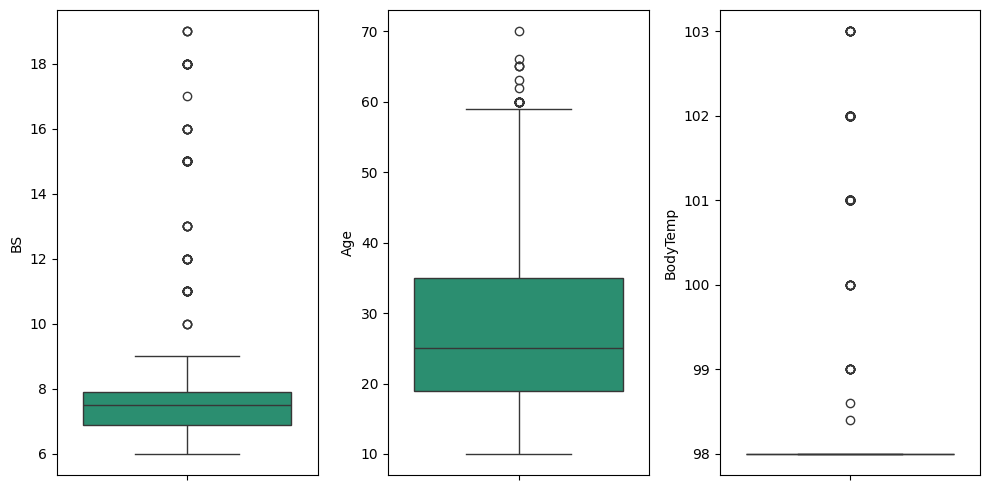

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
sns.boxplot(y = 'BS', data = df)
plt.subplot(1,3,2)
sns.boxplot(y = 'Age', data = df)
plt.subplot(1,3,3)
sns.boxplot(y = 'BodyTemp', data = df)

plt.tight_layout()
plt.show()

EDA

Text(0.5, 1.0, 'Age by Risk Level')

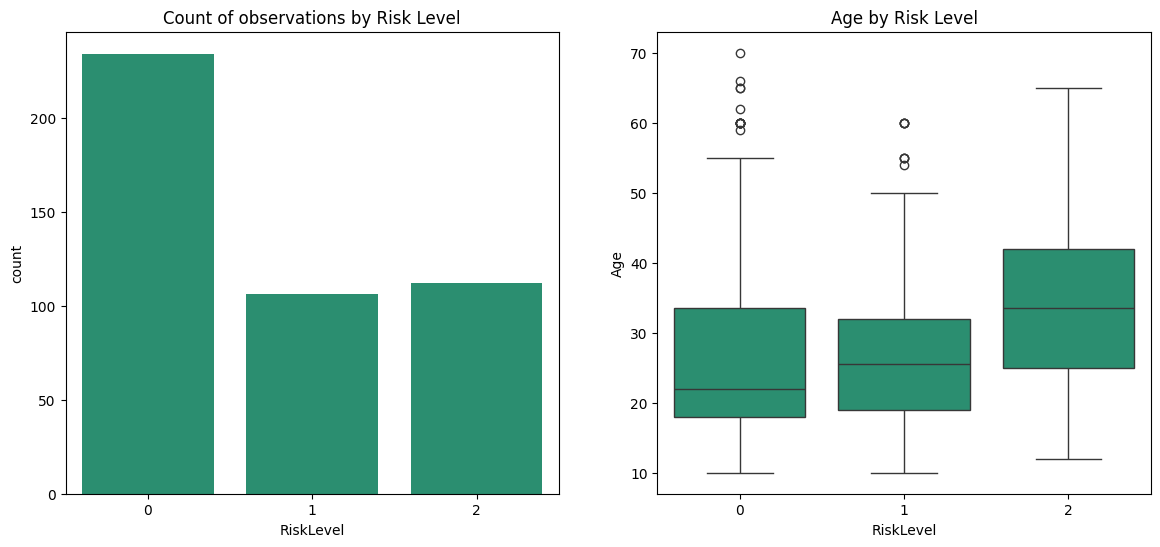

In [22]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.countplot(ax=axes[0], x=df.RiskLevel)
axes[0].set_title("Count of observations by Risk Level")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.Age)
axes[1].set_title("Age by Risk Level")

Blood Glucose Level

Text(0.5, 1.0, 'Blood Glucose by Risk Level')

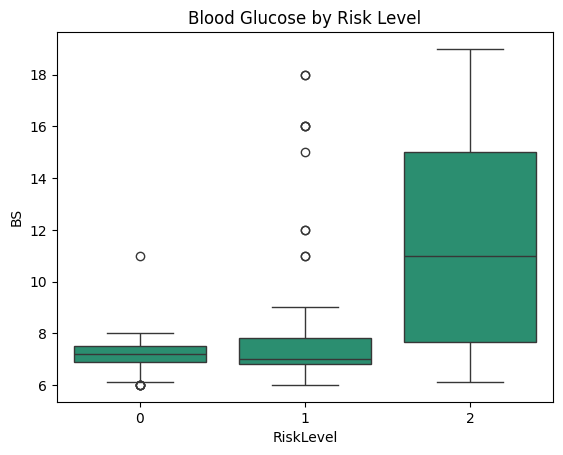

In [23]:
sns.boxplot(x=df.RiskLevel, y=df.BS).set_title("Blood Glucose by Risk Level")

Blood Pressure

Text(0.5, 1.0, 'Distribution of Upper value of Blood Pressure, mmHg')

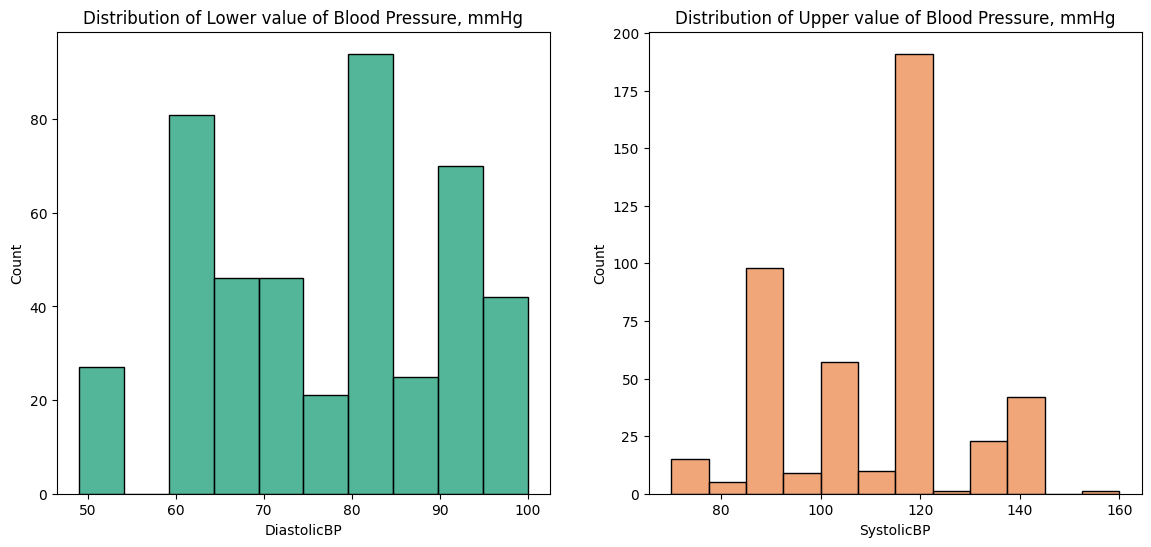

In [24]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.histplot(ax=axes[0], x=df.DiastolicBP)
axes[0].set_title("Distribution of Lower value of Blood Pressure, mmHg")

sns.histplot(ax=axes[1], x=df.SystolicBP, color="#ed894e")
axes[1].set_title("Distribution of Upper value of Blood Pressure, mmHg")

These plots clearly show a positive relationship between blood pressure and risk level: Higher Risk Level → Higher Blood Pressure values
Both systolic and diastolic pressures increase as risk increases.

Text(0.5, 1.0, 'Upper value of Blood Pressure by Risk Level')

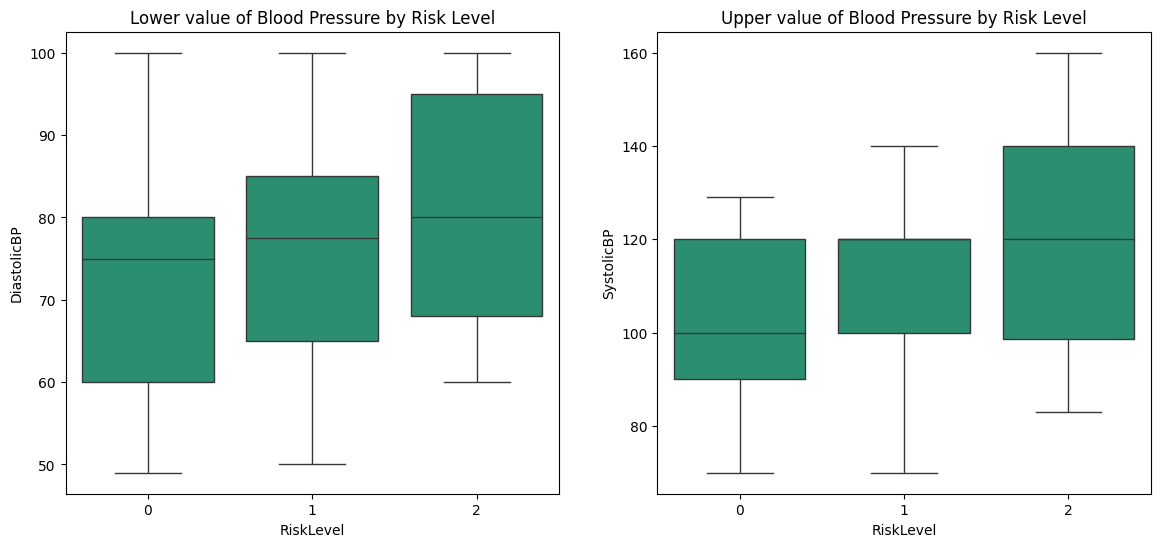

In [25]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.boxplot(ax=axes[0], x=df.RiskLevel, y=df.DiastolicBP)
axes[0].set_title("Lower value of Blood Pressure by Risk Level")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.SystolicBP)
axes[1].set_title("Upper value of Blood Pressure by Risk Level")

Text(0.5, 1.0, 'Upper value of Blood Pressure VS Age')

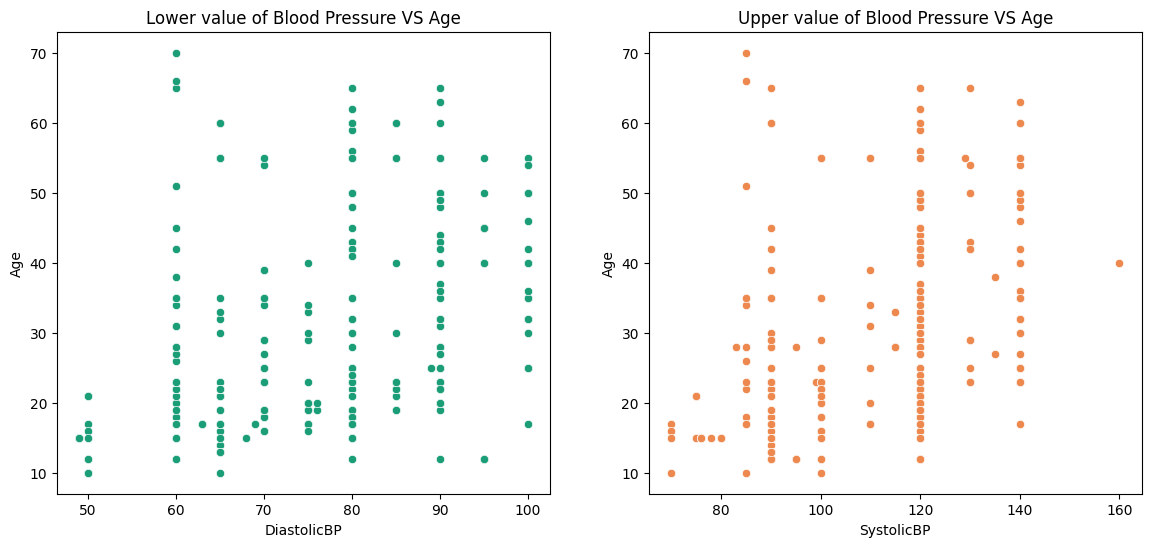

In [26]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.scatterplot(x=df.DiastolicBP, y=df.Age, ax=axes[0])
axes[0].set_title("Lower value of Blood Pressure VS Age")

sns.scatterplot(ax=axes[1], x=df.SystolicBP, y=df.Age, color="#ed894e")
axes[1].set_title("Upper value of Blood Pressure VS Age")

Body Temperature across different Risk Levels.

Text(0.5, 1.0, 'Body Temperature by Risk Level')

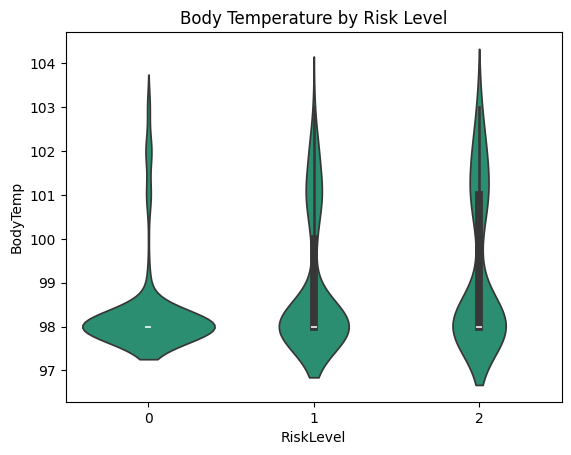

In [27]:
sns.violinplot(y=df.BodyTemp, x=df.RiskLevel).set_title("Body Temperature by Risk Level")

HeartRate

Text(0.5, 1.0, 'Heart Rate by Risk Level')

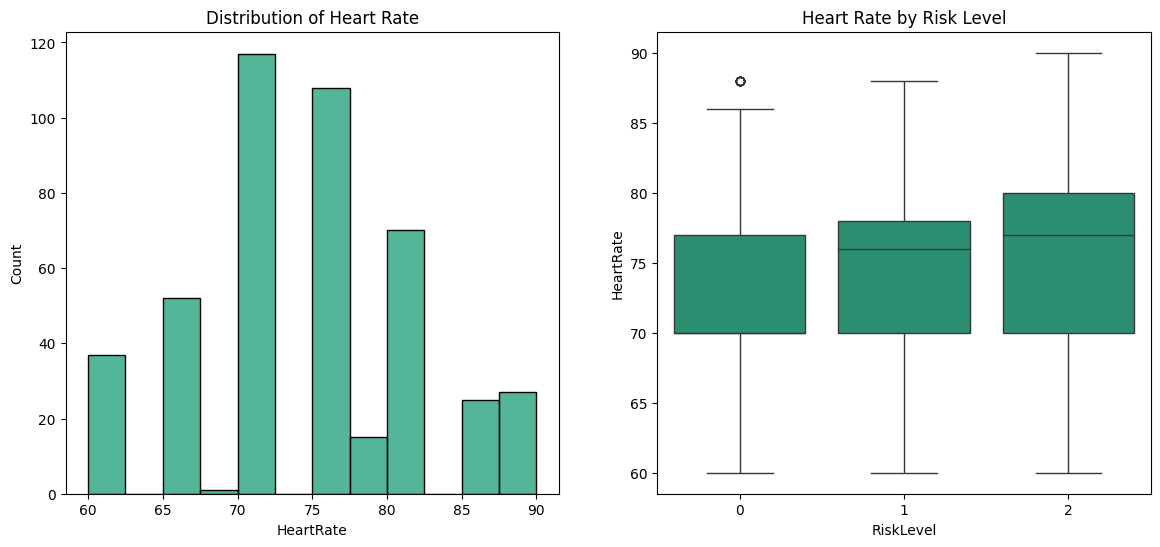

In [28]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14,6))

sns.histplot(ax=axes[0], x=df.HeartRate)
axes[0].set_title("Distribution of Heart Rate")

sns.boxplot(ax=axes[1], x=df.RiskLevel, y=df.HeartRate)
axes[1].set_title("Heart Rate by Risk Level")

Correlations

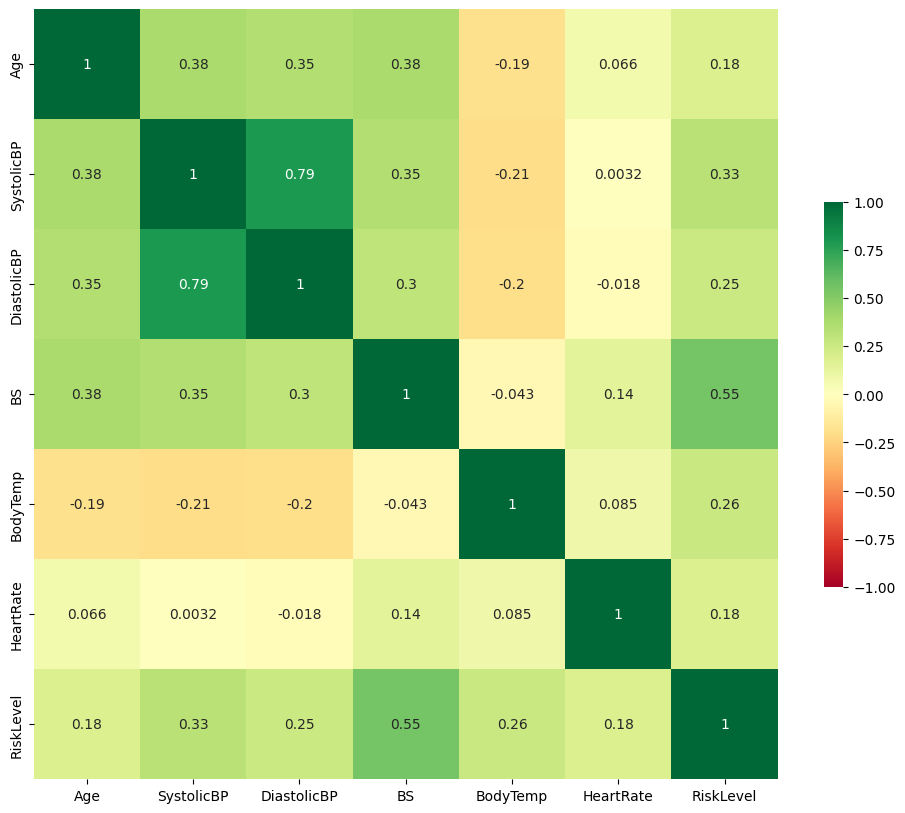

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn', vmin=-1, center=0,
           cbar_kws={"shrink": .5})

plt.show()

Data Preprocessing

Separate features and target

In [ ]:
#Separate features and target
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

Feature Scaling

In [31]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

Train / Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=101, stratify=y)

Split the data into training and testing sets.

In [33]:
# Create and fit a KNN model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Make predictions on the test data
knn_preds = knn.predict(X_test)

Machine Learning Models

KNeighborsClassifier

In [34]:
print('K Nearest Neighbors K=1')
print('\n')
print(confusion_matrix(y_test,knn_preds))
print('\n')
print(classification_report(y_test,knn_preds))

K Nearest Neighbors K=1


[[52 15  3]
 [18  7  7]
 [ 6  6 22]]


              precision    recall  f1-score   support

           0       0.68      0.74      0.71        70
           1       0.25      0.22      0.23        32
           2       0.69      0.65      0.67        34

    accuracy                           0.60       136
   macro avg       0.54      0.54      0.54       136
weighted avg       0.58      0.60      0.59       136



Choosing a K Value

In [35]:
error_rate = []

for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

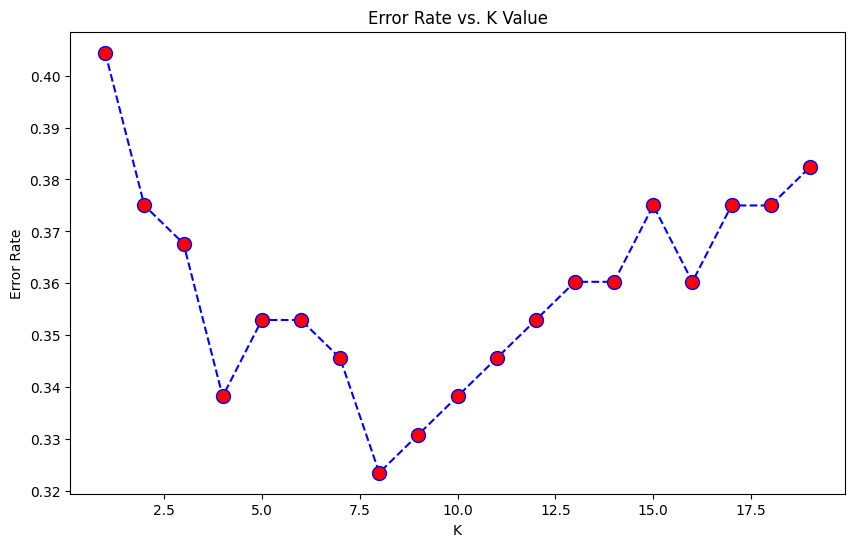

In [36]:
plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, color='blue', linestyle='dashed', marker='o',
        markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate');

In [37]:
knn = KNeighborsClassifier(n_neighbors=16)

knn.fit(X_train,y_train)
knn_preds = knn.predict(X_test)

print('K Nearest Neighbors K=16')
print('\n')
print(confusion_matrix(y_test,knn_preds))
print('\n')
print(classification_report(y_test,knn_preds))

K Nearest Neighbors K=16


[[63  6  1]
 [22  5  5]
 [ 9  6 19]]


              precision    recall  f1-score   support

           0       0.67      0.90      0.77        70
           1       0.29      0.16      0.20        32
           2       0.76      0.56      0.64        34

    accuracy                           0.64       136
   macro avg       0.57      0.54      0.54       136
weighted avg       0.60      0.64      0.60       136



Hypothesis Testing

In this hypothesis testing, we will prove or disapprove that women who are 30 years old and older have higher pregnancy risk level.

In [38]:
under_30 = df.loc[df.Age < 30]
under_30_risk = under_30.RiskLevel
under_mean = under_30_risk.mean()
under_mean

np.float64(0.5878136200716846)

In [39]:
over_30 = df.loc[df.Age >= 30]
over_30_risk = over_30.RiskLevel
over_mean = over_30_risk.mean()
over_mean

np.float64(0.9595375722543352)

In [40]:
df['IsOver30'] = [1 if x >= 30 else 0 for x in df['Age']]

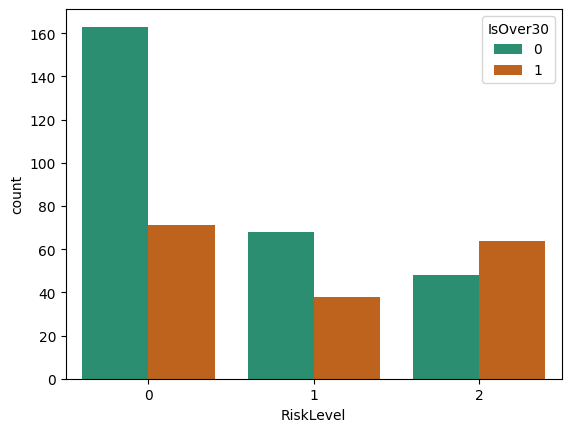

In [41]:
sns.countplot(data=df, x='RiskLevel', hue='IsOver30');